# Burgers PINN — Results

This notebook reads from `outputs/` and refreshes automatically on **Run All**.  
No retraining needed — just run `python main.py` then come back here.

In [8]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

# --- paths ---
OUTPUTS = "outputs/"
MODEL_PT   = os.path.join(OUTPUTS, "model.pt")
HISTORY_CSV = os.path.join(OUTPUTS, "training_history.csv")
METRICS_CSV = os.path.join(OUTPUTS, "metrics.csv")

# --- check everything exists ---
missing = [p for p in [MODEL_PT, HISTORY_CSV, METRICS_CSV] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        f"Missing files: {missing}\n"
        "Run `python main.py` first."
    )

print("All output files found.")

All output files found.


## 1 — Configuration & model reload

In [9]:
import sys
sys.path.insert(0, ".")

from config import Config
from model import PINN

cfg    = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PINN(cfg.layers).to(device)
model.load_state_dict(torch.load(MODEL_PT, map_location=device))
model.eval()

print(f"Model loaded from {MODEL_PT}")
print(f"Architecture : {cfg.layers}")
print(f"Parameters   : {sum(p.numel() for p in model.parameters()):,}")
print(f"Device       : {device}")

Model loaded from outputs/model.pt
Architecture : [2, 64, 64, 64, 64, 1]
Parameters   : 12,737
Device       : cpu


## 2 — Training history

           loss            loss_pde             loss_ic             loss_bc  \
            min      last       min      last       min      last       min   
phase                                                                         
adam   0.001468  0.008119  0.001275  0.007674  0.000013  0.000022  0.000001   
lbfgs  0.000334  0.000334  0.000297  0.000297  0.000003  0.000003  0.000000   

                 
           last  
phase            
adam   0.000044  
lbfgs  0.000001  


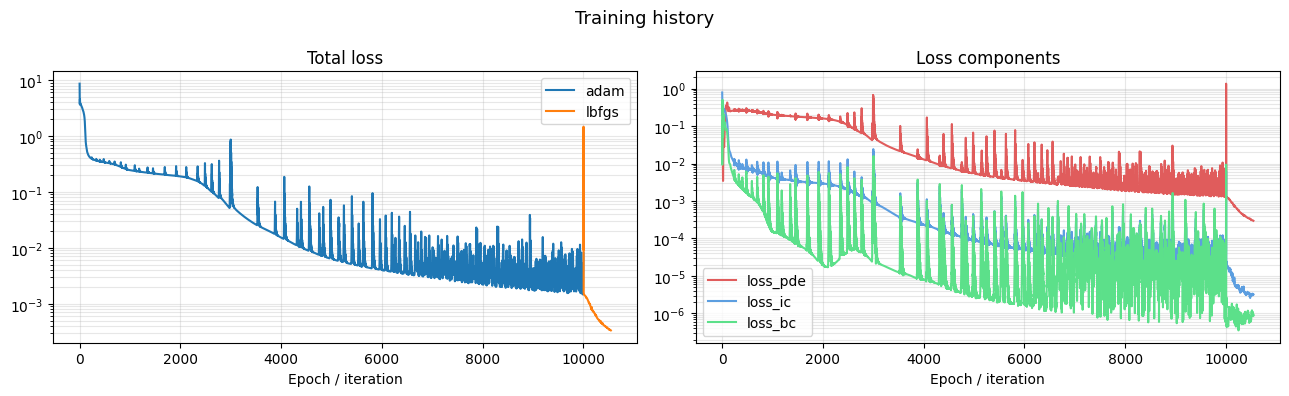

In [10]:
history = pd.read_csv(HISTORY_CSV)

print(history.groupby("phase")[["loss","loss_pde","loss_ic","loss_bc"]]
      .agg(["min", "last"])
      .round(6))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- total loss by phase ---
for phase, grp in history.groupby("phase"):
    axes[0].semilogy(grp["epoch"], grp["loss"], label=phase, lw=1.5)
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch / iteration")
axes[0].legend()
axes[0].grid(which="both", alpha=0.3)

# --- loss components ---
colors = {"loss_pde": "#e05c5c", "loss_ic": "#5c9ee0", "loss_bc": "#5ce08a"}
for col, color in colors.items():
    axes[1].semilogy(history["epoch"], history[col], label=col, color=color, lw=1.5)
axes[1].set_title("Loss components")
axes[1].set_xlabel("Epoch / iteration")
axes[1].legend()
axes[1].grid(which="both", alpha=0.3)

plt.suptitle("Training history", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "loss_history.png"), dpi=150)
plt.show()

## 3 — Exact solution (Cole-Hopf) vs PINN prediction

In [11]:
from evaluate import predict_on_grid, exact_solution, relative_l2, relative_linf

Nx, Nt = 100, 50   # must match main.py grid
x_vec = np.linspace(cfg.x_min, cfg.x_max, Nx)
t_vec = np.linspace(cfg.t_min, cfg.t_max, Nt)

print("Computing PINN prediction …")
U_pred = predict_on_grid(model, x_vec, t_vec, device)

# Use cached exact solution if available (Cole-Hopf is slow to compute)
exact_cache = os.path.join(OUTPUTS, "U_exact.npy")
if os.path.exists(exact_cache):
    print(f"Loading cached exact solution …")
    U_exact = np.load(exact_cache)
else:
    print("Computing Cole-Hopf exact solution (a few minutes) …")
    U_exact = exact_solution(x_vec, t_vec, cfg.nu)
    np.save(exact_cache, U_exact)

l2   = relative_l2(U_pred, U_exact)
linf = relative_linf(U_pred, U_exact)
print(f"\nRelative L2   error : {l2:.4e}")
print(f"Relative L∞   error : {linf:.4e}")

Computing PINN prediction …
Loading cached exact solution …

Relative L2   error : 1.8180e+00
Relative L∞   error : 1.9948e+00


## 4 — Heatmaps

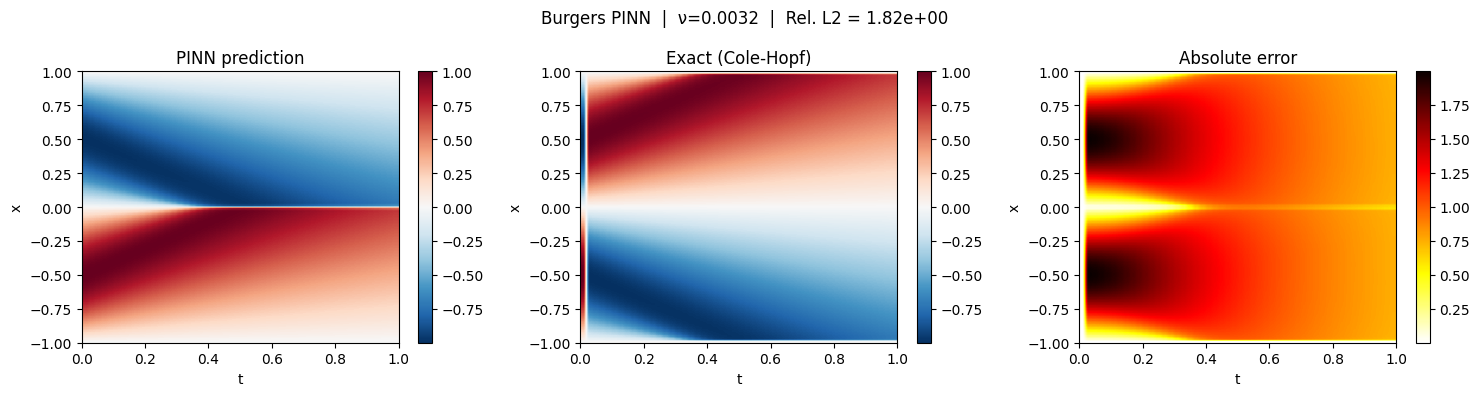

In [12]:
error  = np.abs(U_pred - U_exact)
extent = [t_vec[0], t_vec[-1], x_vec[0], x_vec[-1]]
kw     = dict(aspect="auto", origin="lower", extent=extent)

vmin = min(U_pred.min(), U_exact.min())
vmax = max(U_pred.max(), U_exact.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(U_pred,  cmap="RdBu_r", vmin=vmin, vmax=vmax, **kw)
axes[0].set_title("PINN prediction");  plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_exact, cmap="RdBu_r", vmin=vmin, vmax=vmax, **kw)
axes[1].set_title("Exact (Cole-Hopf)"); plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(error,   cmap="hot_r", **kw)
axes[2].set_title("Absolute error");  plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("t"); ax.set_ylabel("x")

plt.suptitle(
    f"Burgers PINN  |  ν={cfg.nu:.4f}  |  Rel. L2 = {l2:.2e}",
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "heatmaps.png"), dpi=150)
plt.show()

## 5 — Time slices

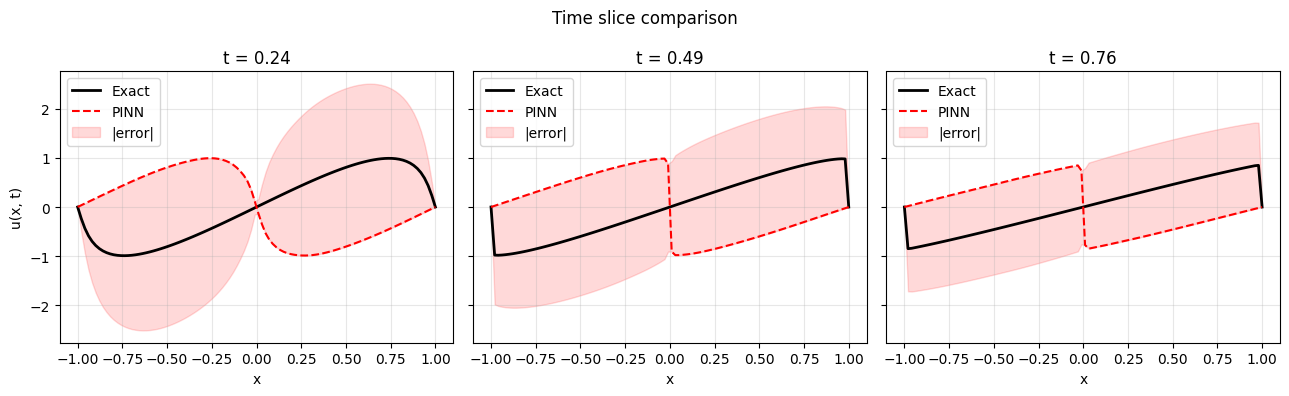

In [13]:
t_slices = [0.25, 0.50, 0.75]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, t_target in zip(axes, t_slices):
    j = np.argmin(np.abs(t_vec - t_target))
    ax.plot(x_vec, U_exact[:, j], "k-",  lw=2,   label="Exact")
    ax.plot(x_vec, U_pred[:, j],  "r--", lw=1.5, label="PINN")
    ax.fill_between(x_vec,
                    U_exact[:, j] - error[:, j],
                    U_exact[:, j] + error[:, j],
                    alpha=0.15, color="red", label="|error|")
    ax.set_title(f"t = {t_vec[j]:.2f}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("u(x, t)")
plt.suptitle("Time slice comparison", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "slices.png"), dpi=150)
plt.show()

## 6 — Metrics summary

In [14]:
metrics = pd.read_csv(METRICS_CSV).set_index("metric")

# Refresh with current notebook computation
metrics.loc["relative_l2",   "value"] = l2
metrics.loc["relative_linf", "value"] = linf

# Add training stats
adam_df  = history[history.phase == "adam"]
lbfgs_df = history[history.phase == "lbfgs"]

summary = {
    "Relative L2 error":      f"{l2:.4e}",
    "Relative L∞ error":      f"{linf:.4e}",
    "Adam epochs":            len(adam_df),
    "Adam final loss":        f"{adam_df['loss'].iloc[-1]:.4e}",
    "L-BFGS iterations":      len(lbfgs_df),
    "L-BFGS final loss":      f"{lbfgs_df['loss'].iloc[-1]:.4e}" if len(lbfgs_df) else "N/A",
    "Total training time (s)": f"{history['elapsed'].iloc[-1]:.1f}",
    "Network architecture":   str(cfg.layers),
    "Parameters":             sum(p.numel() for p in model.parameters()),
    "nu (viscosity)":         cfg.nu,
}

df_summary = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
df_summary.index.name = "Metric"
display(df_summary)

,Value
Metric,
Relative L2 error,1.8180e+00
Relative L∞ error,1.9948e+00
Adam epochs,10000
Adam final loss,8.1190e-03
L-BFGS iterations,544
L-BFGS final loss,3.3386e-04
Total training time (s),2165.7
Network architecture,"[2, 64, 64, 64, 64, 1]"
Parameters,12737
